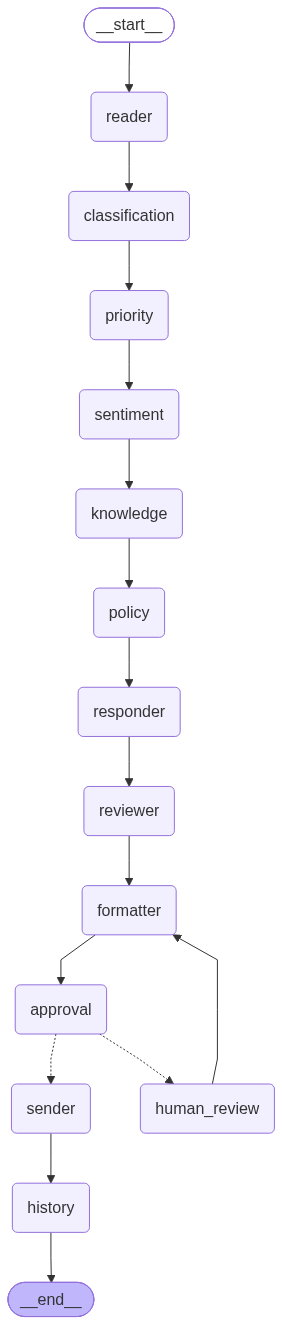

In [1]:
# ==========================================
# Enterprise AI Email Automation - LangGraph
# Workflow Visualization
# ==========================================

!pip install -q langgraph

from typing import TypedDict
from langgraph.graph import StateGraph
from IPython.display import Image, display

# ==========================================
# State
# ==========================================

class EmailState(TypedDict):
    email: str
    summary: str
    category: str
    priority: str
    sentiment: str
    knowledge: str
    policy_result: str
    draft_reply: str
    reviewed_reply: str
    final_email: str
    approval_status: str
    send_status: str

# ==========================================
# Agent Nodes
# ==========================================

def reader(state):
    return state

def classification(state):
    return state

def priority(state):
    return state

def sentiment(state):
    return state

def knowledge(state):
    return state

def policy(state):
    return state

def responder(state):
    return state

def reviewer(state):
    return state

def formatter(state):
    return state

def approval(state):
    return state

def sender(state):
    return state

def history(state):
    return state

def human_review(state):
    return state

# ==========================================
# Decision Function
# ==========================================

def approval_router(state):

    if state.get("approval_status") == "approved":
        return "sender"

    return "human_review"

# ==========================================
# Build Graph
# ==========================================

builder = StateGraph(EmailState)

builder.add_node("reader", reader)
builder.add_node("classification", classification)
builder.add_node("priority", priority)
builder.add_node("sentiment", sentiment)
builder.add_node("knowledge", knowledge)
builder.add_node("policy", policy)
builder.add_node("responder", responder)
builder.add_node("reviewer", reviewer)
builder.add_node("formatter", formatter)
builder.add_node("approval", approval)
builder.add_node("sender", sender)
builder.add_node("human_review", human_review)
builder.add_node("history", history)

# ==========================================
# Entry Point
# ==========================================

builder.set_entry_point("reader")

# ==========================================
# Workflow
# ==========================================

builder.add_edge("reader","classification")

builder.add_edge("classification","priority")

builder.add_edge("priority","sentiment")

builder.add_edge("sentiment","knowledge")

builder.add_edge("knowledge","policy")

builder.add_edge("policy","responder")

builder.add_edge("responder","reviewer")

builder.add_edge("reviewer","formatter")

builder.add_edge("formatter","approval")

# ==========================================
# Conditional Approval
# ==========================================

builder.add_conditional_edges(

    "approval",

    approval_router,

    {
        "sender":"sender",
        "human_review":"human_review"
    }

)

builder.add_edge("human_review","formatter")

builder.add_edge("sender","history")

# ==========================================
# Finish
# ==========================================

builder.set_finish_point("history")

graph = builder.compile()

# ==========================================
# Visualize
# ==========================================

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [2]:
# Save LangGraph image
png = graph.get_graph().draw_mermaid_png()

with open("Enterprise_AI_Email_Workflow.png", "wb") as f:
    f.write(png)

print("✅ Image saved successfully.")

✅ Image saved successfully.


In [3]:
from google.colab import files

files.download("Enterprise_AI_Email_Workflow.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
from PIL import Image

img = Image.open("Enterprise_AI_Email_Workflow.png")

# Convert to RGB if needed
if img.mode == "RGBA":
    img = img.convert("RGB")

img.save("Enterprise_AI_Email_Workflow.pdf", "PDF", resolution=100.0)

print("PDF created successfully.")

PDF created successfully.


In [5]:
from google.colab import files

files.download("Enterprise_AI_Email_Workflow.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>